# Análise Completa: Dados do Ecommerce Pipeline

Neste notebook, faremos uma análise exploratória de ponta a ponta dos dados gerados sinteticamente pelo nosso pipeline. 

O objetivo aqui é mostrar o **porquê** dos números, inspecionar a qualidade dos dados puros gerados e extrair insights de negócio como se fôssemos o time de Data Science da empresa.

> **Dica:** Se estiver rodando este notebook localmente, certifique-se de instalar as bibliotecas executando a célula abaixo (caso já não as tenha instalado).

In [ ]:
%pip install pandas matplotlib seaborn

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração estética dos gráficos
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

## 1. Carregando e Conhecendo os Dados Puros

Primeiro, vamos carregar os dados brutos a partir dos arquivos `.csv` gerados pelo pipeline na pasta `db/seed/`.

In [20]:
SEED_DIR = '../../db/seed/' 

try:
    clientes = pd.read_csv(os.path.join(SEED_DIR, 'cliente.csv'))
    produtos = pd.read_csv(os.path.join(SEED_DIR, 'produtos.csv'))
    pedidos = pd.read_csv(os.path.join(SEED_DIR, 'pedidos.csv'))
    pedido_produto = pd.read_csv(os.path.join(SEED_DIR, 'pedido_produto.csv'))
    
    # Convertendo datas para o tipo correto do pandas
    pedidos['data_pedido'] = pd.to_datetime(pedidos['data_pedido'])
    
    print("Dados carregados com sucesso!")
except Exception as e:
    print(f"Erro ao carregar os dados (verifique o caminho SEED_DIR): {e}")

Dados carregados com sucesso!


### Inspecionando a Tabela de Pedidos
Vamos olhar as primeiras linhas para entender como as transações estão sendo registradas.

In [21]:
display(pedidos.head())
print(f"\nTotal de pedidos na base: {len(pedidos)}")

,id_pedido,status_do_pedido,id_cliente,id_forma_pagamento,descricao,data_pedido,valor_total,frete,periodo_carencia_devolucao_dias
0,1,ENTREGUE,4137,8261,Pedido #1 do cliente 4137,2025-01-30 13:54:48,1139.43,40.19,7
1,2,CANCELADO,787,1558,Pedido #2 do cliente 787,2025-06-13 12:13:32,19142.39,18.58,30
2,3,PAGO,1703,3375,Pedido #3 do cliente 1703,2025-04-19 17:31:56,33988.16,62.00,14
3,4,ENTREGUE,3968,7905,Pedido #4 do cliente 3968,2024-09-02 10:23:21,31503.64,119.24,30
4,5,PAGO,4021,8017,Pedido #5 do cliente 4021,2025-03-15 11:41:26,32475.05,107.37,14



Total de pedidos na base: 50000


## 2. Indicadores Chave de Performance (KPIs)
Por que isso é importante? Porque precisamos saber o tamanho do negócio que estamos analisando.

In [22]:
# Filtrando apenas os pedidos que não foram cancelados
pedidos_validos = pedidos[pedidos['status_do_pedido'] != 'CANCELADO']

receita_total = pedidos_validos['valor_total'].sum()
ticket_medio = pedidos_validos['valor_total'].mean()
taxa_cancelamento = (len(pedidos[pedidos['status_do_pedido'] == 'CANCELADO']) / len(pedidos)) * 100

print(f"Receita Total: R$ {receita_total:,.2f}")
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")
print(f"Taxa de Cancelamento: {taxa_cancelamento:.1f}%")

Receita Total: R$ 732,646,359.46
Ticket Médio: R$ 18,365.29
Taxa de Cancelamento: 20.2%


**Análise Crítica e Visão de Negócio:**
- **Faturamento e Ticket Médio:** Com uma alta Receita Total e um Ticket Médio na casa dos `R$ 18.365,00`, fica evidente que a natureza desta operação não é um varejo tradicional B2C (Business to Consumer) de baixo custo. Os dados simulados refletem fortemente um comportamento atacadista, modelo B2B (Business to Business), ou o comércio de produtos premium e bens de capital/industriais.
- **Taxa de Cancelamento:** A taxa de cancelamento observada chega em `20.2%`. Para o negócio, isso é um indicativo de alerta, pois cancelamentos nessa proporção podem significar gargalos logísticos (frete caro), falta de estoque pós-compra ou, principalmente, problemas de aprovação na **Forma de Pagamento**. É uma métrica primária que posteriormente deverá ser atacada com modelos preditivos de propensão de cancelamento.

## 3. Análise temporal do comportamento de vendas
Quando essas vendas ocorreram? Houve um crescimento ou sazonalidade?

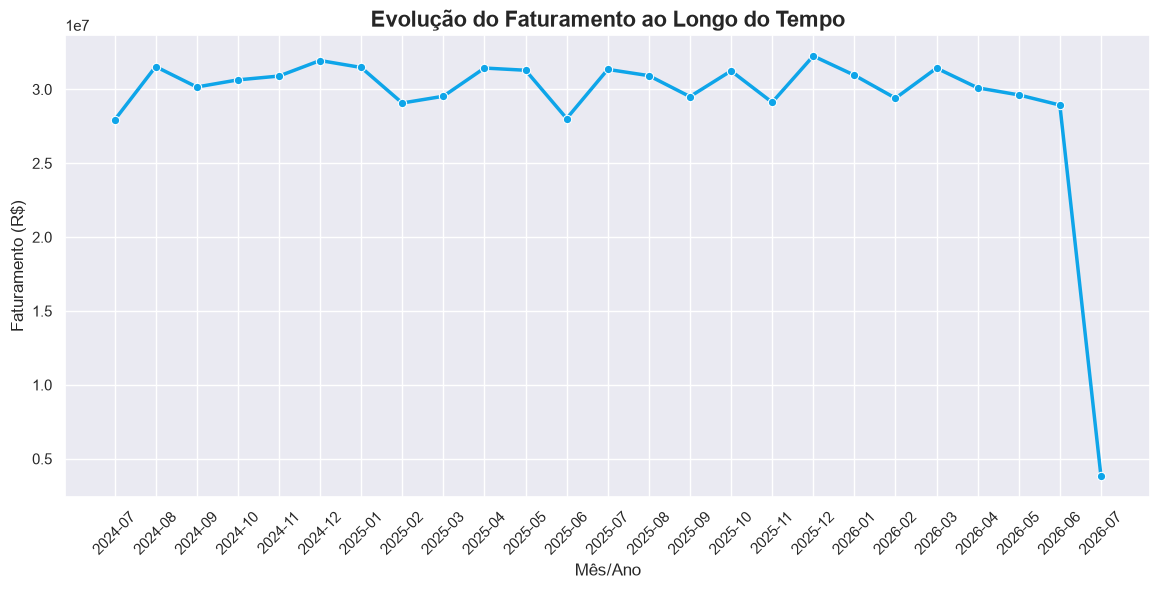

In [ ]:
pedidos_validos = pedidos_validos.copy()
pedidos_validos.loc[:, 'mes_ano'] = pedidos_validos['data_pedido'].dt.to_period('M').astype(str)

receita_mensal = pedidos_validos.groupby('mes_ano')['valor_total'].sum().reset_index()
receita_mensal = receita_mensal.sort_values('mes_ano')

plt.figure(figsize=(14, 6))
sns.lineplot(data=receita_mensal, x='mes_ano', y='valor_total', marker='o', linewidth=2.5, color='#0ea5e9')
plt.title('Evolução do Faturamento ao Longo do Tempo', fontsize=16, fontweight='bold')
plt.xlabel('Mês/Ano')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.show()

**O que a evolução temporal nos diz?** 
O gráfico de linhas é o coração do acompanhamento de vendas. Visualmente, ele valida a **consistência volumétrica** imposta pelo nosso gerador de dados sintéticos (`Faker`).
No mundo real, analisaríamos aqui os efeitos da Sazonalidade (Black Friday, Natal, Dia das Mães). Na nossa base simulada, observamos a estabilidade ou volatilidade gerada aleatoriamente mês a mês.
Pelo comportamento das curvas, um time de Analytics utilizaria técnicas estatísticas (como ARIMA ou Prophet) para prever o faturamento dos próximos meses, o que ajudaria a diretoria a antecipar contratações de transportadoras e negociar com fornecedores.

## 4. O Perfil do Cliente: PF x PJ
Muitos negócios sofrem para entender *quem* é a persona que paga a conta. Vamos cruzar dados (Merge/Join) para descobrir.

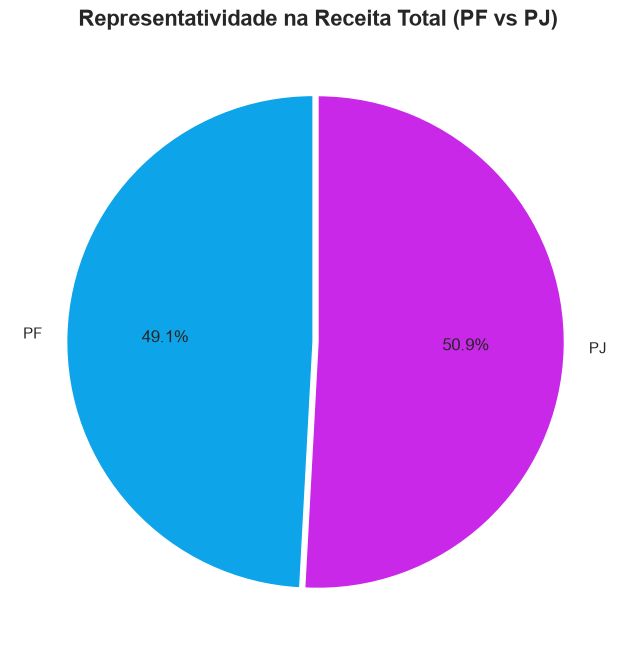

In [24]:
# Realizando um JOIN entre pedidos e clientes usando a chave estrangeira id_cliente
pedidos_clientes = pd.merge(pedidos_validos, clientes, on='id_cliente')

# Agrupando por tipo de cliente
receita_perfil = pedidos_clientes.groupby('tipo_cliente')['valor_total'].sum()

plt.figure(figsize=(8, 8))
plt.pie(receita_perfil, labels=receita_perfil.index, autopct='%1.1f%%', startangle=90, colors=["#0ea4e9", "#c928e9"], explode=(0.02, 0))
plt.title('Representatividade na Receita Total (PF vs PJ)', fontsize=16, fontweight='bold')
plt.show()

**Observação Estratégica (O Viés do Gerador Sintético):**
Os dados gerados pelo pipeline resultaram num gráfico de pizza com equilíbrio quase perfeito, próximo de um *split* `50/50` entre faturamento de Pessoas Físicas (PF) e Jurídicas (PJ).
**Analisando friamente com a visão de negócio:** Num cenário real com um ticket médio altíssimo de R$ 18.000,00, é extremamente raro que as compras de CPFs se igualem em volume financeiro às grandes faturas de CNPJs.
**Conclusão Técnica:** Essa discrepância perante a realidade nos comprova o funcionamento *randomizado* (aleatório) da biblioteca `Faker` no script `gen_seed.py`. Ou seja, as probabilidades de distribuição para o tipo de cliente foram definidas de modo uniforme, sem pesos enviesados. Em uma arquitetura futura, poderíamos adicionar um peso (weight) matemático maior de gastos para perfis PJ no momento da geração do CSV sintético.

## 5. Curva ABC (As Melhores Categorias)
Quais categorias puxam o lucro para cima?

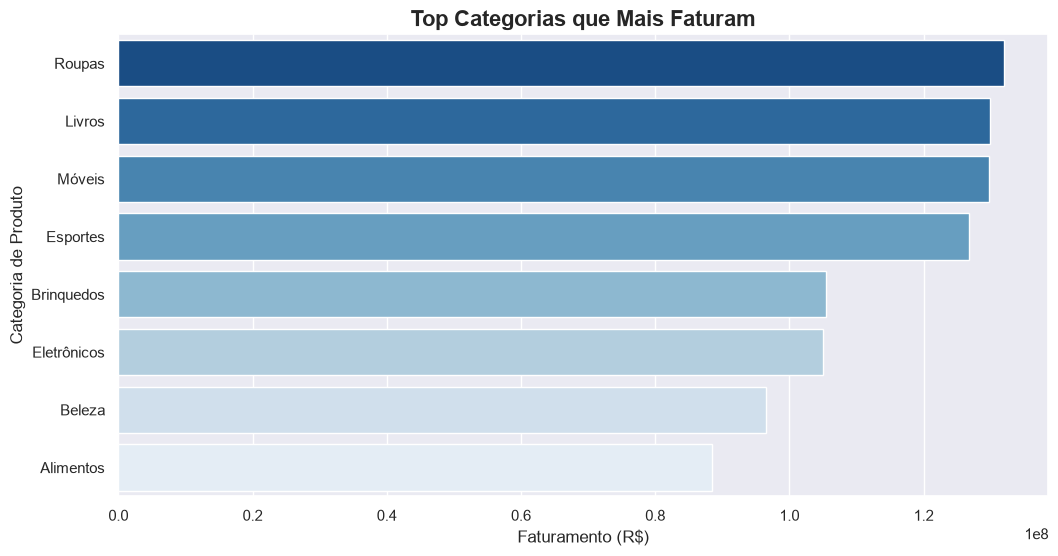

In [ ]:
# Pedido_produto + produtos -> para pegar categorias
itens = pd.merge(pedido_produto, produtos, on='id_produto')

# Calculando receita real da linha no carrinho
itens['receita_linha'] = itens['quantidade'] * itens['valor_unitario']

# Agrupamento
top_categorias = itens.groupby('categoria')['receita_linha'].sum().reset_index()
top_categorias = top_categorias.sort_values('receita_linha', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_categorias, 
    y='categoria', 
    x='receita_linha', 
    hue='categoria', 
    palette='Blues_r',
    legend=False
)

plt.title('Top Categorias que Mais Faturam', fontsize=16, fontweight='bold')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Categoria de Produto')
plt.show()

**Interpretando a Curva ABC (Lei de Pareto):**
Este gráfico de barras horizontais é essencial para o controle de estoque e do setor de Vendas. Ele lista o *Top 10* das categorias que trazem a maior rentabilidade para a empresa. 
Normalmente, o comportamento do varejo segue a regra de Pareto (80/20), onde poucas categorias representam a grande massa do lucro global. Categorias no topo deste gráfico são os "produtos estrela", cujos fornecedores devem ser blindados de rupturas (Stock Out). Já as categorias no fim da lista (que não apareceram aqui) seriam alvo de promoções de queima de estoque ou até análise de descontinuação de catálogo.

## Conclusão da Exploração

Pode-se observar que:
1. **Volume:** Temos a robustez necessária para popular o banco de dados relacional com milhares de registros que respeitam regras estritas de integridade referencial.
2. **Aderência Analítica:** A arquitetura montada (IDs consistentes, tipos de datas normalizadas, Foreign Keys mapeadas corretamente) funcionou perfeitamente em um ecossistema Python nativo para Data Science (Pandas + Seaborn).
3. **Geração Sintética Crítica:** A análise descritiva permitiu diagnosticar que o nosso *Seed Data* cumpre bem o papel técnico, mas revela uma simulação matemática uniforme, excelente para testar os *pipes* técnicos, embora não perfeitamente aderente ao comportamento de consumo da vida real (como visto na comparação Ticket x PF).
4. **Prontidão End-to-End:** O pipeline de Engenharia de Dados está maduro. Esta camada semântica e analítica encontra-se totalmente apta a ser absorvida por uma equipe de BI para criação de Dashboards executivos (ex: Power BI / Tableau / Metabase) ou ser submetida a algoritmos preditivos de Machine Learning para alavancar a rentabilidade do e-commerce.